# Iris Dataset

* El Iris Dataset es una excelente elección para comenzar. Es pequeño, limpio y clásico para practicar clasificación multiclase.
* Sobre el Iris Dataset
    * Objetivo: Clasificar una flor como una de tres especies de Iris:
         - Iris setosa
         - Iris versicolor
         - Iris virginica

    * Características (features):
         - Largo del sépalo (sepal length)
         - Ancho del sépalo (sepal width)
         - Largo del pétalo (petal length)
         - Ancho del pétalo (petal width)
    * Tamaño: 150 muestras (50 por especie)

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Clasificación vs Regresión

* Clasificación:
  - Su objetivo es predecir categorías o clases.
  - Su target o salida sería spam o no spam.
  - Los modelos comunes para este son: Regresión Logística, Árboles, SVM, k-NN.
  - Las metricas son: Recall, F1, AUC.
  - Algunos resultados podrían ser 0, 1 o 'setosa', 'versicolor'.

* Regresión:
  - Predecir valores numéricos continuos.
  - Su target son Números reales (por ejemplo: precio, temperatura).
  - Los modelo más comunes son Regresión lineal, Random Forest Regressor etc.
  - Las metricas son: MSE, RMSE, MAE, R²

* ¿Cómo saber cuál aplicar?
  - Si tu variable objetivo (target) es categórica → usa clasificación.
  - Si tu variable objetivo es numérica continua → usa regresión.

* Ejemplos prácticos
  - Diagnóstico de enfermedad (sí o no): ***Clasificación binaria***
  - Clasificación de imágenes de animales: ***Clasificación multiclase***
  - Predecir ingresos mensuales: ***Regresión***
  - Determinar si un cliente dejará el servicio: ***Clasificación binaria***
  - Estimar la puntuación de una película: ***Regresión***

* Consejo para identificarlo fácilmente.
  - Mira tu columna objetivo (y o target):
    * ¿Tiene nombres, categorías o etiquetas? (ej: 'alto', 'medio', 'bajo') → Clasificación.
    * ¿Tiene números continuos? (ej: 1.5, 78.3) → Regresión

```python
df['target'].value_counts()  # Si ves pocos valores repetidos → Clasificación
df['target'].describe()      # Si ves min, max, std → Probablemente regresión
```


### 1.Cargar y entender el data

* Al igual que el dataset de diabetes este es un diccionario que puede ser transformado a dataframe.
* Parece haber 3 tipos de clasificaciones: `'setosa', 'versicolor', 'virginica'`.
* El target tiene 3 tipos de valores [0, 1, 2], supongo que  hacen referencia al index de las 3 clasificaciones.
* Al parecer cada flor tiene 4 variables `'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'`.
* El objetivo del dataset es ***predecir*** a cuál de estas tres ***especies*** de flores Iris pertenece una muestra, ***en base a 4 medidas físicas***.
* Todas son especies del género Iris, muy similares visualmente, pero medibles por tamaño de pétalo y sépalo.
* Los pétalos suelen tener mayor variabilidad entre especies, y son clave para diferenciarlas.
* Tipos Especies:
  - **setosa**: Pétalos pequeños, bien diferenciada.
  - **versicolor**: Características intermedias.
  - **virginica**: Pétalos más largos, a veces se confunde.
* Tipos de Variables
  - **sepal length (cm)**: Longitud del sépalo (la hoja que protege el capullo)
  - **sepal width (cm)**: Ancho del sépalo
  - **petal length (cm)**: Longitud del pétalo (parte colorida de la flor)
  - **petal width (cm)**: Ancho del pétalo

In [2]:
iris = load_iris()
#iris = load_iris(as_frame=True)
iris

# Ver la forma de los datos
print("\nForma de X (data):", iris.data.shape)
print("Forma de y (target):", iris.target.shape)

# Ver las primeras 5 muestras
print("\nPrimeras 5 muestras:")
print(iris.data[:5])
print(iris.target[:5])

# Ver los nombres de las clases
print("\nClases posibles (target_names):", iris.target_names)

# Ver nombres de características
print("\nNombres de características (feature_names):", iris.feature_names)


Forma de X (data): (150, 4)
Forma de y (target): (150,)

Primeras 5 muestras:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]

Clases posibles (target_names): ['setosa' 'versicolor' 'virginica']

Nombres de características (feature_names): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 2. Exploración y visualización (EDA)

* Por lo que veo estos datos no están siendo estandarizados.
* Creo que no puedo hacer scalerMinMax, ya puede que una especie de flor tenga valores muy altos en comparación de otras especias.
* ¿Sería correcto hacer 3 dataframes o mejor hacer un gruopBy?

In [3]:
# Crear DataFrame con los datos
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Agregar la columna 'species' con nombres en texto
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df)
print("\nCantidad de muestras por especie:")
print(df['species'].value_counts())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

       species  
0       se

* ¿Qué es pairplot?
  - Es una función de la biblioteca Seaborn que dibuja todas las combinaciones posibles de gráficos de dispersión (scatterplots) entre las variables numéricas de un DataFrame, además de los histogramas en la diagonal.

* ¿Qué muestra exactamente?
  - Imagina que tienes 4 columnas numéricas como en Iris: A, B, C, D
  - Entonces pairplot crea una matriz 4x4 con los siguientes componentes:
![Diagrama_Pairplot](Pairplot.png)

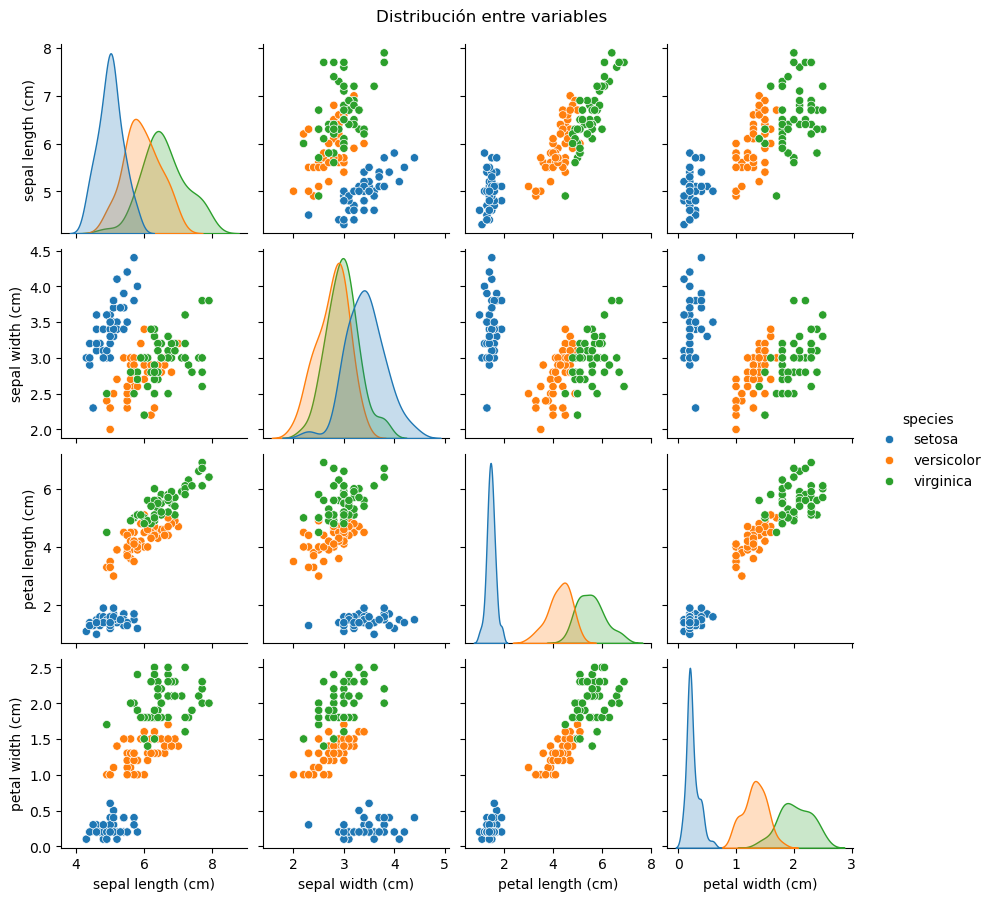

In [4]:
# Crear pairplot (muy útil para ver cómo se separan las clases)
sns.pairplot(df, hue='species', height=2.2)
plt.suptitle("Distribución entre variables", y=1.02)
plt.show()

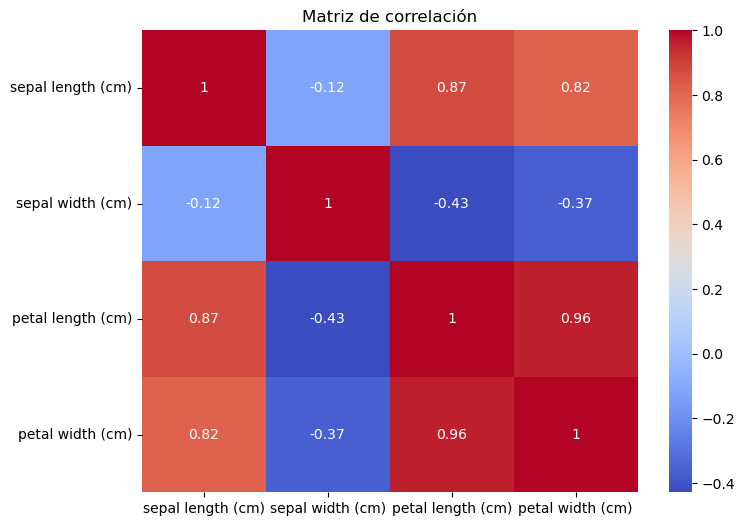

In [5]:
# Ver correlación entre variables
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

### 2.1 Visualización por Especie.

* Iris Setosa:
  - sepal length, sepal width y petal length siguen una distribución normal.
* Iris Versicolor
  - petal length, petal width parecen que siguen una ligera distribución normal.
  - Se ve una correlación positiva entre sepal length y petal width.
* Iris Virginica
  - sepal length, sepal width siguen una distribución normal.

In [6]:
# Crear DataFrames separados por especie
df_setosa = df[df['species'] == 'setosa']
df_versicolor = df[df['species'] == 'versicolor']
df_virginica = df[df['species'] == 'virginica']

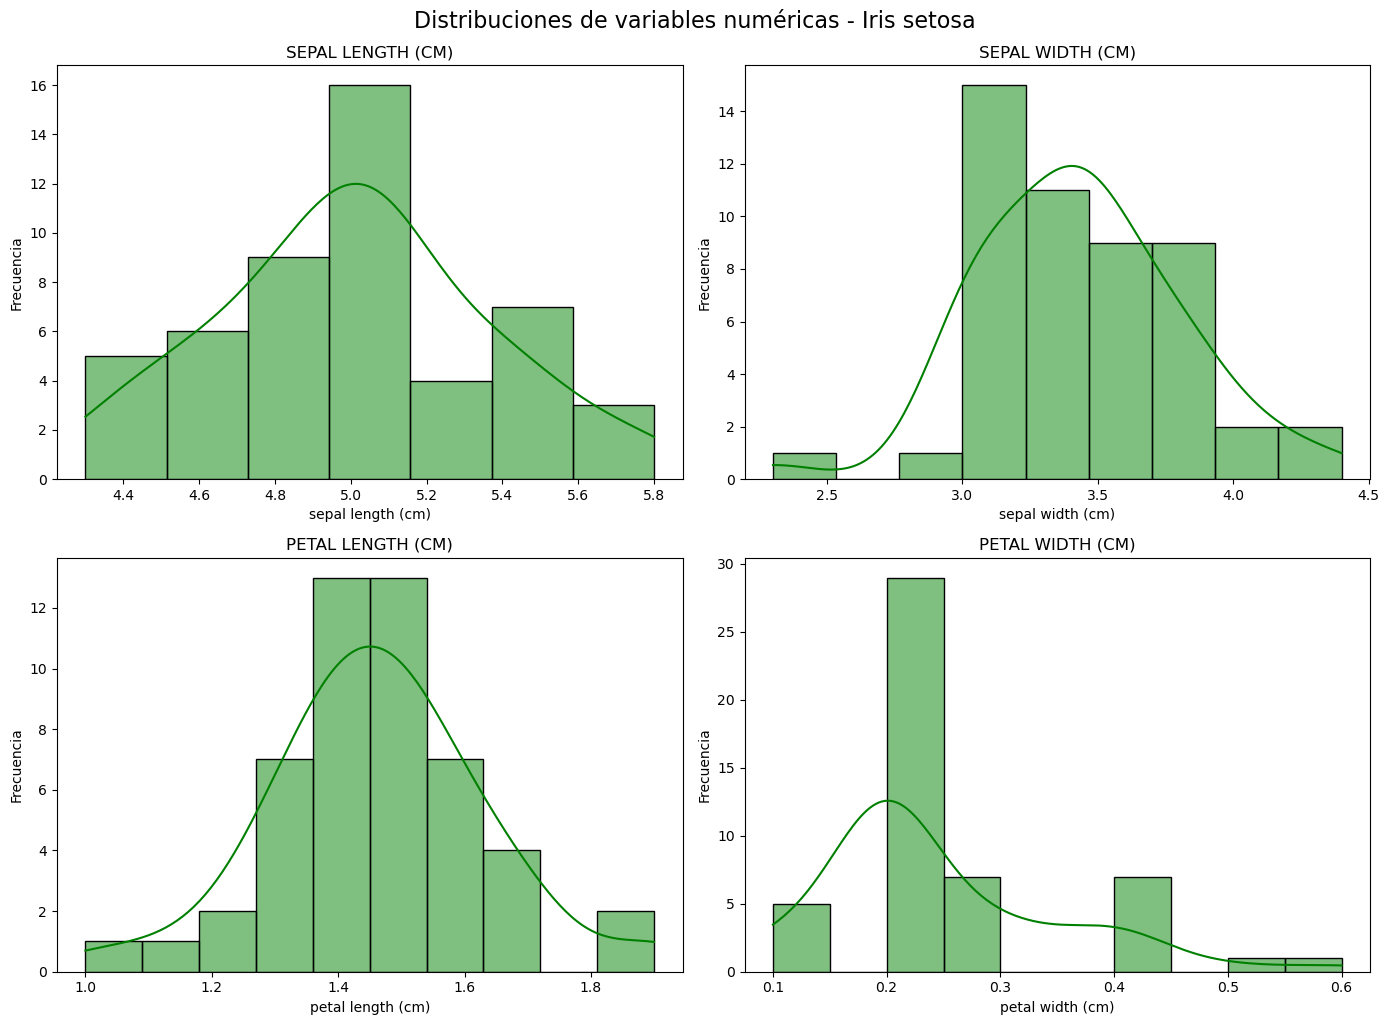

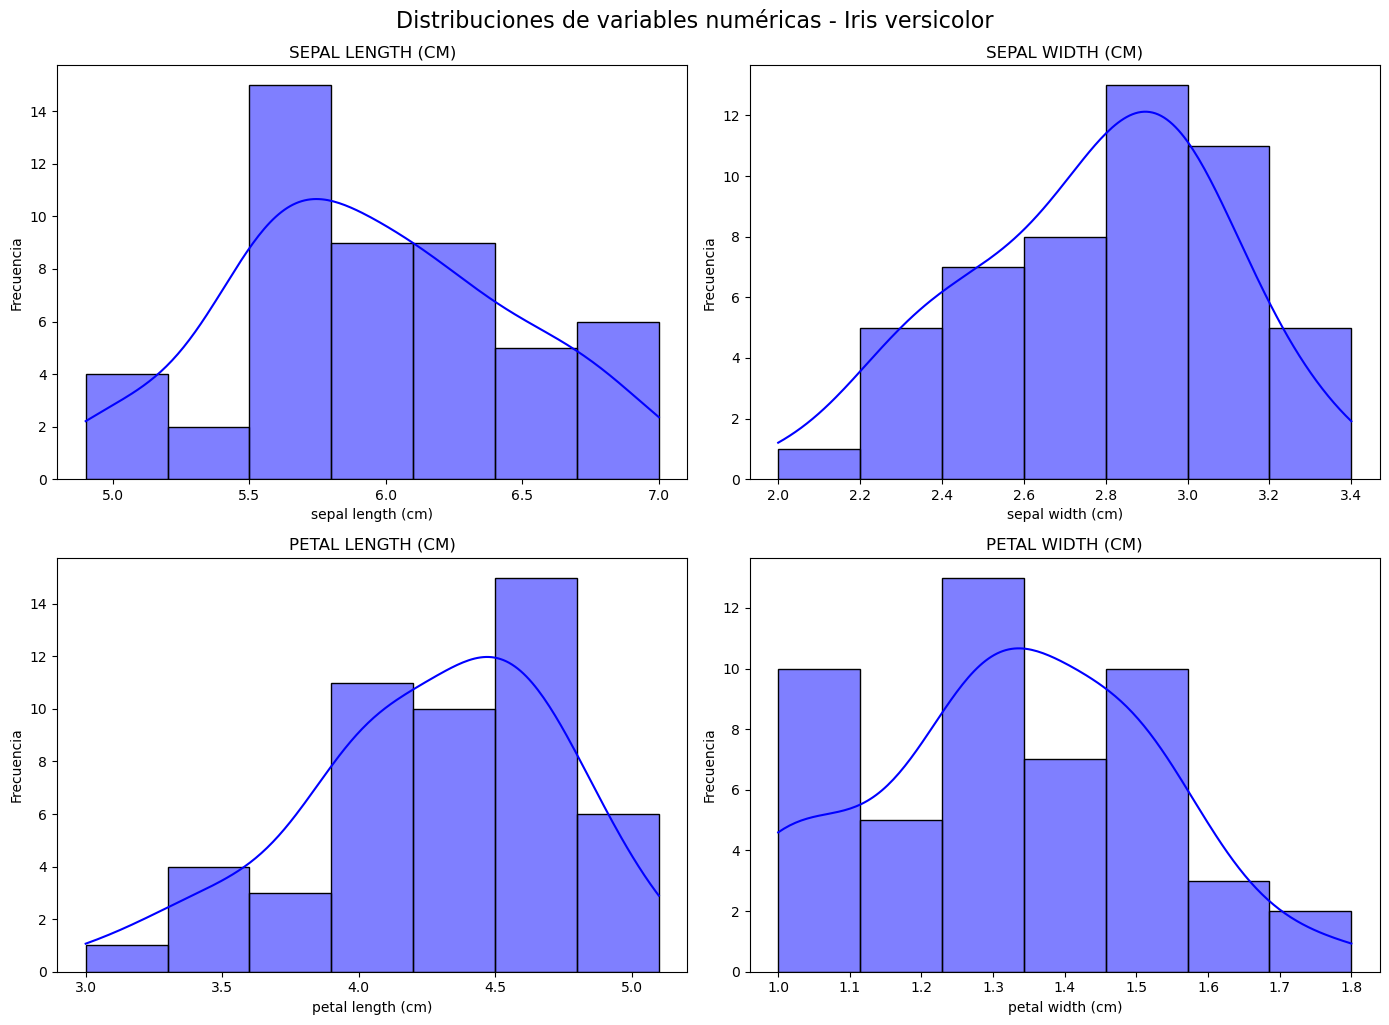

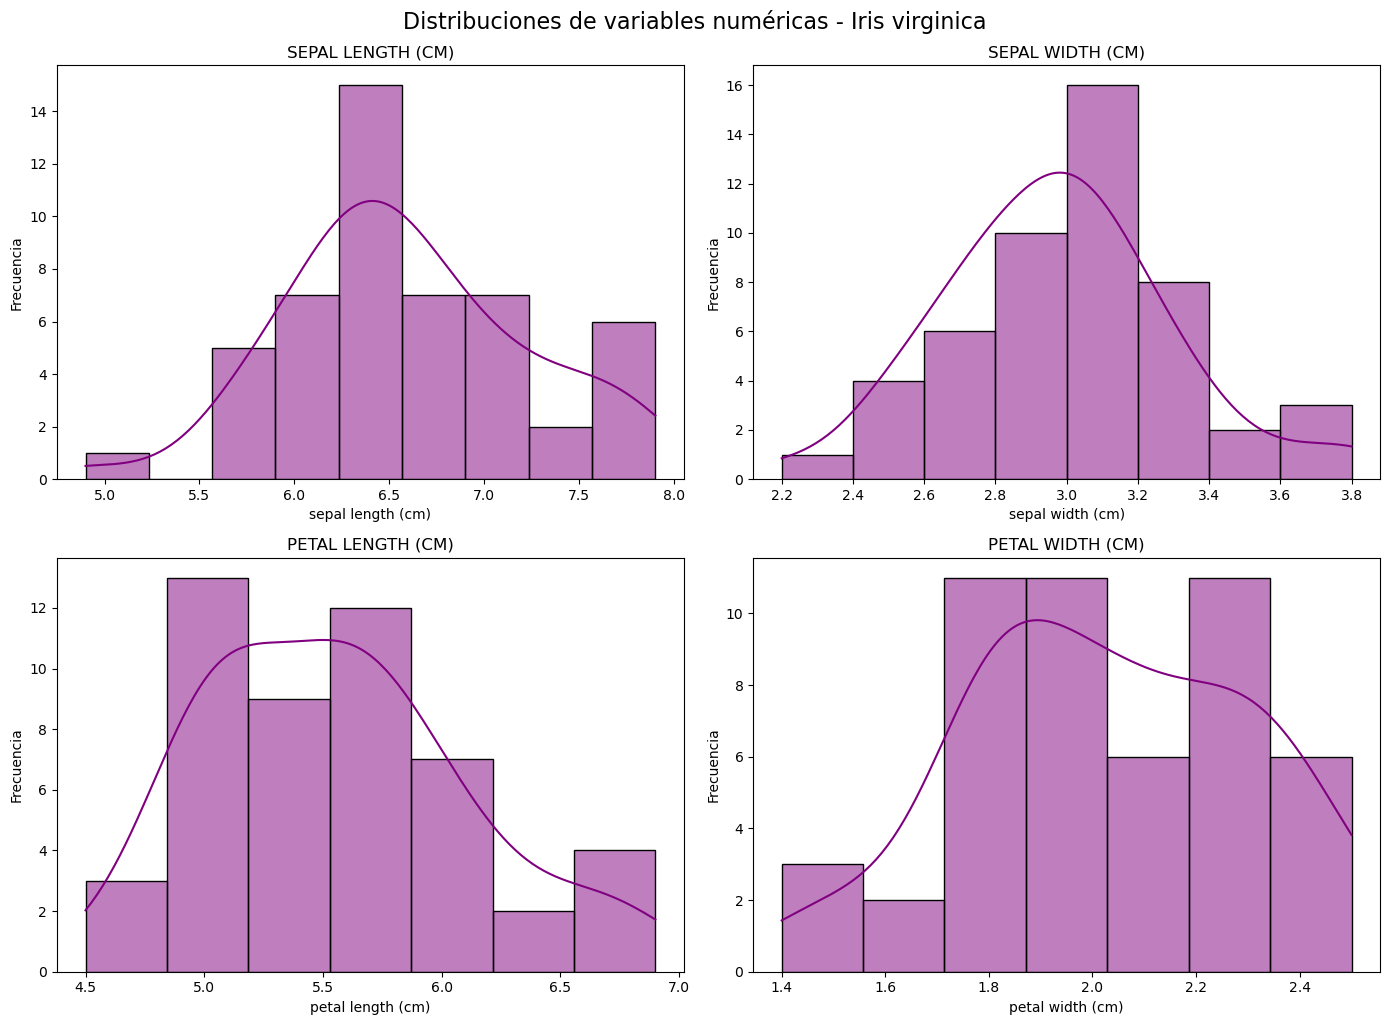

In [7]:
# Crear una función para graficar histogramas por especie
def plot_histograms_por_especie(df_especie, nombre_especie, color):
    numeric_cols = df_especie.select_dtypes(include='number').columns
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, column in enumerate(numeric_cols):
        sns.histplot(df_especie[column], kde=True, ax=axes[idx], color=color)
        axes[idx].set_title(column.upper())
        axes[idx].set_xlabel(column)
        axes[idx].set_ylabel("Frecuencia")

    # Eliminar ejes sobrantes si hay menos columnas que subplots
    if len(numeric_cols) < len(axes):
        for j in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(f"Distribuciones de variables numéricas - Iris {nombre_especie}", fontsize=16, y=1.02)
    plt.show()

# Ejecutar función para cada especie
plot_histograms_por_especie(df_setosa, 'setosa', 'green')
plot_histograms_por_especie(df_versicolor, 'versicolor', 'blue')
plot_histograms_por_especie(df_virginica, 'virginica', 'purple')

* sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
* Iris Setosa:
  - Se ve una correlación positiva entre sepal length y sepal width.
* Iris Versicolor
  - Se ve una correlación positiva entre sepal length y petal length.
  - Se ve una correlación positiva entre petal length y petal width.
  - Se ve una ligera correlación positiva entre sepal width y petal width.
* Iris Virginica
  - Se ve una correlación positiva entre sepal length y petal length.

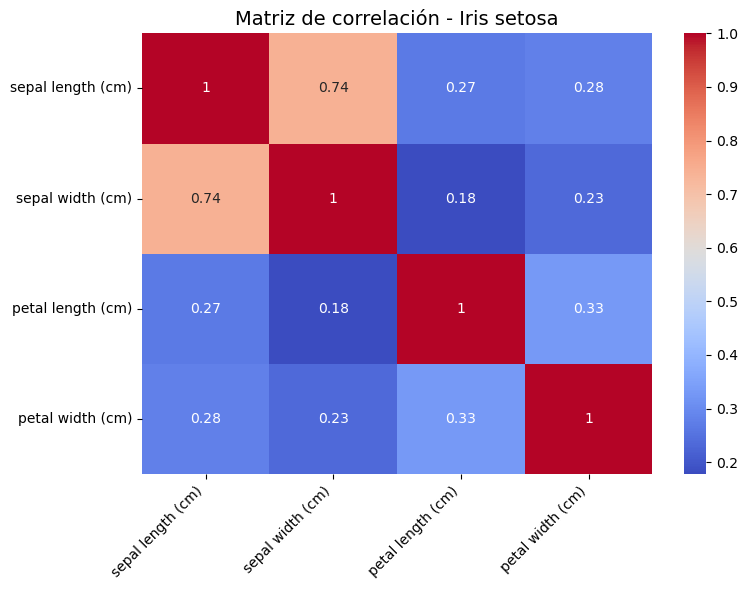

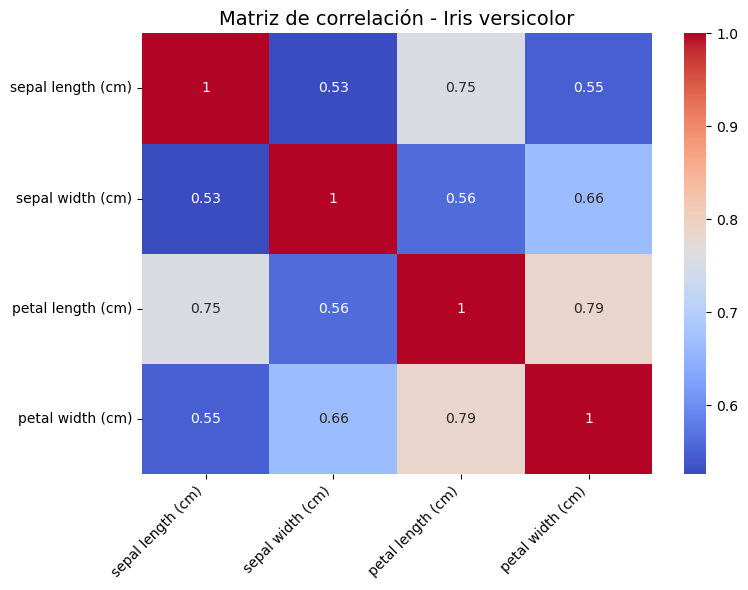

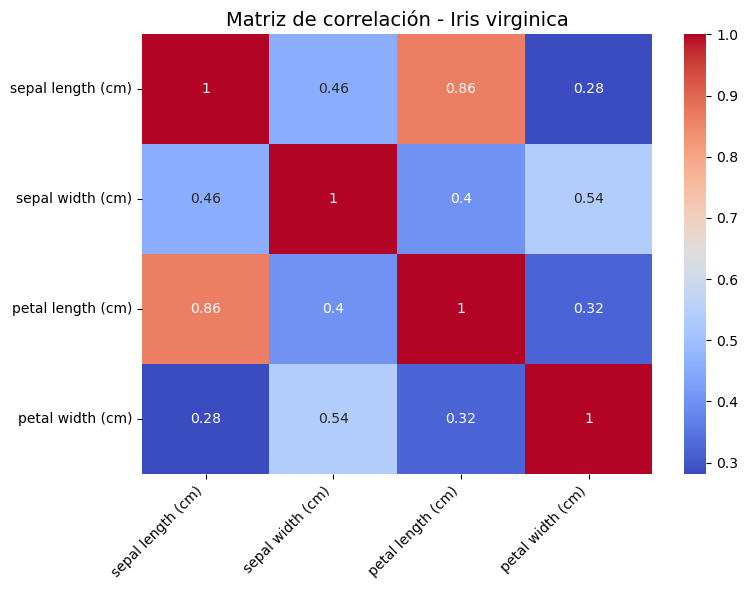

In [8]:
# Función para graficar la matriz de correlación por especie
def plot_heatmap_por_especie(df_especie, nombre_especie):
    numeric_cols = df_especie.select_dtypes(include='number')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", xticklabels=True, yticklabels=True)
    plt.title(f"Matriz de correlación - Iris {nombre_especie}", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Llamadas para cada especie
plot_heatmap_por_especie(df_setosa, "setosa")
plot_heatmap_por_especie(df_versicolor, "versicolor")
plot_heatmap_por_especie(df_virginica, "virginica")

### 3. Preparación de los datos

* `LabelEncoder` es una herramienta de `scikit-learn` que se usa para convertir etiquetas categóricas (texto) a números, lo cual es necesario para muchos algoritmos de machine learning.
* ¿Por qué convertir texto a números?
  - Muchos modelos de scikit-learn no aceptan strings como clases.
  - Los modelos necesitan una representación numérica discreta para calcular cosas como probabilidades o funciones de pérdida.
  - Es más eficiente computacionalmente.
* ¿Es mejor usar `LabelEncoder`?
  - Usar modelos de scikit-learn que requieren etiquetas numéricas como: LogisticRegression, KNeighborsClassifier SVC, RandomForestClassifier, etc.
  - Quieres evitar problemas con métricas como classification_report o confusion_matrix, que pueden esperar etiquetas numéricas por defecto.
  - Necesitas consistencia al comparar modelos o al guardar etiquetas en un archivo/exportación.
* ¿Qué pasa si no se usa?
  - Dar problemas si usas algunas funciones que no manejan bien strings como etiquetas.
  - Hacer que el orden de las clases no esté claro en algunos reportes o visualizaciones.
  - Complicar un poco el análisis de resultados si las clases están desordenadas.
* train_test_split:
  - X	Son tus características o variables independientes (tu matriz de entrada).
  - y_encoded	Son tus etiquetas o clases (variables objetivo), codificadas como números (0, 1, 2).
  - test_size=0.2	Indica que el 20% de los datos se reservarán para prueba y el 80% para entrenamiento.
  - random_state=42	Fija una semilla aleatoria para que la división sea reproducible. Cambiar este número generará una partición diferente cada vez.   (Puedes usar cualquier número, 42 es un clásico 😉).
  - stratify=y_encoded	Garantiza que la proporción de clases (setosa, versicolor, virginica) se mantenga igual en los conjuntos de entrenamiento y prueba. Muy recomendable si tus clases no están equilibradas.
* ¿Qué hace StandardScaler?
  - StandardScaler transforma tus variables para que tengan: Media = 0 y Desviación estándar = 1.
  - Los algoritmos que calculan distancias o usan funciones de optimización sensibles a la magnitud de los datos se ven muy afectados si las variables tienen escalas diferentes.
  - Sin escalado, el modelo podría dar más peso a las variables con valores grandes aunque no sean más importantes.
  - Modelos que necesitan escalado (funcionan mejor o incluso requieren escalado): Regresión Logística, SVM (Support Vector Machines), KNN (K-Nearest Neighbors), PCA, Redes Neuronales.

***Notas***
* Sin random_state: Cada vez que ejecutes el código, la división será distinta.
* Sin stratify: Puede que el conjunto de prueba tenga una proporción desigual de clases, lo que afecta la evaluación del modelo.
* ¿Si espeficas el train_test_split ya no es necesario el test_size? No, no es necesario ni recomendable usar ambos a la vez, a menos que quieras ser muy específico. Si usas solo uno, scikit-learn calcula el otro automáticamente.

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separamos X y y
X = df[iris.feature_names]         # Características
y = df['species']                  # Etiquetas en texto

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)    # y_encoded tendrá 0, 1, 2

# Dividir usando y codificado también el resultado este codificado.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

# Instanciamos nuestro scalador para poner todos los valores.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Entrenamiento de modelos

* ¿Por qué usamos “Regresión” si el problema es de Clasificación?
  - Sí, el nombre "Logistic Regression" puede confundir un poco. A pesar del nombre, `LogisticRegression` es un modelo de clasificación, no de regresión como el usado en el dataset de diabetes.
  - Internamente logistic regression modela la probabilidad de una clase usando una función sigmoide (logística) aplicada a una combinación lineal de las variables.
  - Aunque usa una base lineal, su salida está entre 0 y 1 → se convierte en clasificación al asignar la clase con mayor probabilidad.
* ¿Qué significa `max_iter=200` en `LogisticRegression`?
  - Especifica el número máximo de iteraciones que usará el algoritmo para encontrar los mejores parámetros (coeficientes).
  - Por defecto usa `max_iter=100`, pero a veces no es suficiente, así que es común subirlo a 200 o más.
  - Si no pones un número suficiente, puede no entrenar correctamente (quedarse a mitad de camino).
* `accuracy_score(y_test, y_pred)`:
  - mide la exactitud o proporción de predicciones correctas sobre el total de ejemplos.
  - Es una métrica sencilla y rápida para saber cuántos ejemplos clasificaste bien, pero no siempre es suficiente, sobre todo si las clases están desbalanceadas.
  - Si 18 de 20 predicciones fueron correctas, la accuracy será 0.9 (90%).
* `classification_report(y_test, y_pred, target_names=iris.target_names)`:
  - Te permite ver en detalle el desempeño por clase y no solo un promedio global.
  - Incluye un reporte completo que muestra para cada clase:
    * `Precision`: qué porcentaje de las predicciones de esa clase fueron correctas.
    * `Recall (sensibilidad)`: qué porcentaje de los casos reales de esa clase fueron detectados.
    * `F1-score`: la media armónica entre precision y recall, útil para balancear ambos.
    * `Support`: cuántos ejemplos reales hay en esa clase. 
* `confusion_matrix(y_test, y_pred)`:
  - Visualizar qué clases se confunden entre sí te ayuda a entender errores específicos del modelo.
  - Muestra una matriz cuadrada que indica:
    * En diagonal: cuántos ejemplos de cada clase fueron correctamente clasificados.
    * Fuera de diagonal: cuántos ejemplos fueron confundidos con otras clases.

***Notas***:
* Tu modelo clasificó correctamente el 93.3% de los ejemplos del conjunto de prueba (30 ejemplos).
* Classification Report
  - Setosa: 10/10 clasificadas perfectamente. Tu modelo no cometió ningún error con esta clase.
  - Versicolor y Virginica: 9/10 clasificadas correctamente; el modelo confundió 1 de cada una.
* Confusion Matrix
  - 1 versicolor fue clasificado erróneamente como virginica.
  - 1 virginica fue clasificado erróneamente como versicolor.

```python
Setosa, Versicolor, Virginica
[[10      0          0]  → setosa
 [ 0      9          1]  → versicolor
 [ 0      1          9]]  → virginica
```

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear y entrenar el modelo
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred = model.predict(X_test_scaled)

# Evaluar el rendimiento del modelo
# Exactitud
print("Accuracy:", accuracy_score(y_test, y_pred))

# Reporte de métricas por clase
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de confusión
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


### 5. Comparación contra Modelos

* Explicación rápida de los modelos
  - `KNN`: Clasifica según los k vecinos más cercanos
  - `SVC`: Encuentra la mejor frontera entre clases
  - `Árbol de decisión`: Usa reglas tipo "si-entonces"
  - `Random Forest`: Conjunto de árboles de decisión (más robusto)
* ¿Todos estos modelos son solo para clasificación?
  - Sí. Los modelos que estás usando en este proyecto con el dataset de Iris son todos modelos de clasificación.
  - Aunque tambien existen algunos modelos para la Regresión.
  - Muchos algoritmos en scikit-learn tienen dos versiones: `Regressor` → para predicción de valores continuos (números reales). `Classifier` → para predecir clases (categorías).
* ¿Por qué para el dataset de diabetes usamos MSE y R²?
  - El dataset de diabetes es un problema de regresión, no de clasificación.
  - MSE (Mean Squared Error): mide qué tan lejos están en promedio tus predicciones del valor real.
  - R² (Coeficiente de determinación): mide qué tanto del comportamiento del valor objetivo está explicado por el modelo (1.0 es perfecto, 0 es como adivinar la media).
  - Estas no tienen sentido en clasificación, porque ahí no estás prediciendo números reales, sino categorías.

***Notas***
* En clasificación → usamos métricas como accuracy, precision, recall, f1-score, etc.
* En regresión → usamos métricas como MSE, MAE, R², etc.
* Muchos algoritmos tienen versiones para ambos tipos de problemas (Classifier y Regressor)
* `KNN – K-Nearest Neighbors Classifier`:
  - Clasifica un dato nuevo mirando las K muestras más cercanas (en distancia) en el conjunto de entrenamiento.
  - La clase más común entre esos vecinos es la que se asigna.
  - Ejemplo: Si k=3 y los 3 vecinos más cercanos son 2 "setosa" y 1 "versicolor" → el modelo clasifica como "setosa".
  - Ventaja: Fácil de entender, no necesita entrenamiento complejo.
  - Desventaja: Lento con grandes datasets, sensible a escala (por eso usamos StandardScaler).
* `SVC – Support Vector Classifier`:
  - Encuentra la mejor frontera (hiperplano) que separa las clases maximizando la distancia entre los puntos más cercanos (los "vectores de soporte").
  - Funciona bien cuando: Las clases son separables o casi separables y Se usa un kernel (como 'rbf') para manejar separaciones no lineales.
  - Ventaja: Preciso y robusto.
  - Desventaja: Puede ser lento con datasets muy grandes.
* `Decision Tree Classifier`:
  - Usa una estructura tipo "árbol" con reglas de "si-entonces" para clasificar.
  - Divide los datos según la característica que mejor separa las clases en cada paso.
  - Ejemplo de regla: "Si petal width < 0.8 → setosa"
  - Ventaja: Muy interpretable, rápido.
  - Desventaja: Puede sobreajustarse si no se controla la profundidad.
* `Random Forest Classifier`:
  - Es un conjunto (ensemble) de muchos árboles de decisión, entrenados con diferentes partes del dataset.
  - Hace una votación entre los árboles para decidir la clase final.
  - Ventaja: Más robusto que un solo árbol, reduce el sobreajuste.
  - Desventaja: Más complejo, menos interpretable que un solo árbol.
* `Logistic Regression`:
  - Modela la probabilidad de que una muestra pertenezca a cada clase.
  - Asigna la clase con la mayor probabilidad.
  - Ventaja: Rápido, simple, buen modelo base.
  - Desventaja: No funciona bien si las clases no son linealmente separables.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Diccionario para almacenar resultados
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVC": SVC(kernel='rbf', C=1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entrenar y evaluar cada modelo
for nombre, modelo in modelos.items():
    print(f"\n🔹 Modelo: {nombre}")
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


🔹 Modelo: KNN
Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

🔹 Modelo: SVC
Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

🔹 Modelo: Decision Tr

* El modelo con mejor desempeño (`SVC`) y el que tuvo el peor (`Random Forest`), para entender por qué les fue mejor o peor. A veces una accuracy alta puede ocultar errores importantes en una clase específica.
* Modelo Ganador: SVC (Support Vector Classifier):
  - Accuracy: 0.97
  - Solo un error: clasificó 1 versicolor como virginica.
  - setosa y virginica fueron perfectamente clasificadas.
  - F1-scores: [1.00, 0.95, 0.95]
  - Muy alto rendimiento, equilibrado y consistente.
* Segundo lugar: KNN (k=3):
  - Accuracy: 0.93
  - Confundió 2 virginica como versicolor.
  - setosa y versicolor → clasificación perfecta.
  - F1-scores: [1.00, 0.91, 0.89]
  - Parece que KNN tiene problemas distinguiendo entre versicolor y virginica, algo común porque están más cerca entre sí en el espacio de características.
* Etc.

### 6. Visualización de resultados

* Vamos a visualizar la frontera de decisión de los modelos usando PCA (Análisis de Componentes Principales) para reducir las dimensiones a 2D. Esto nos permitirá ver cómo el modelo separa las clases en el espacio.
* ¿Qué vamos a hacer?
  - Reducir las características a 2D usando PCA.
  - Entrenar nuevamente el modelo con los datos reducidos.
  - Dibujar la frontera de decisión.
  - Mostrar los puntos reales (clases) y cómo fueron clasificados.

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

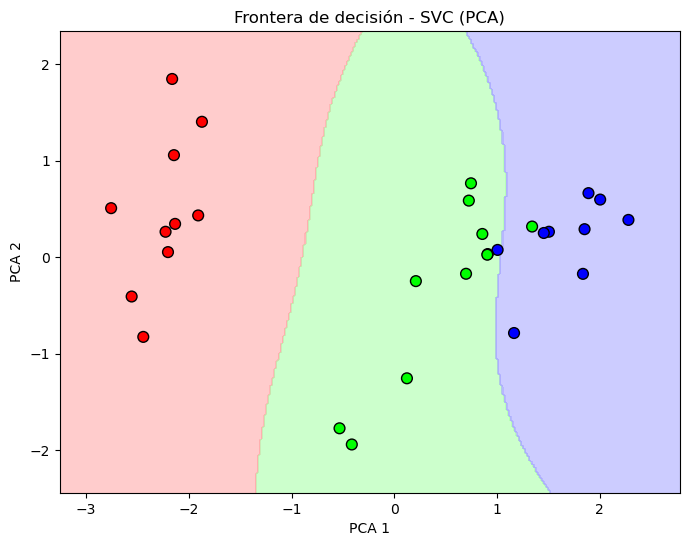

In [22]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Codificar etiquetas (string a entero)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0, 1, 2

# Dividir datos (usar etiquetas codificadas para stratify)
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA para reducción a 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar modelo SVC con datos PCA
svc_pca = SVC(kernel='rbf', C=1)
svc_pca.fit(X_train_pca, y_train_encoded)

# Función para graficar frontera de decisión
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=60)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(title)

    # 🔧 Corrección aquí:
    handles, _ = scatter.legend_elements()
    plt.legend(handles=handles, labels=le.classes_)  # usar le.classes_ para etiquetas

    plt.grid(True)
    plt.show()

# Visualizar frontera de decisión
plot_decision_boundary(X_test_pca, y_test_encoded, svc_pca, "Frontera de decisión - SVC (PCA)")

### 7. (Opcional) Tuning de hiperparámetros

### 8. (Opcional) Reducción de dimensionalidad